<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Decision%20Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  Diagnosis  
0  26.455940                  0.272682  20.100494          0  
1  23.910167                  0.665160  44.912281          0  
2  21.948250                  0.676022  48.247873          1  
3  24.209304                  0.289636  42.749868          0  
4  32.997477                  0.601315  32.797789          0  

Dataset Shape:
(1000, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diagno

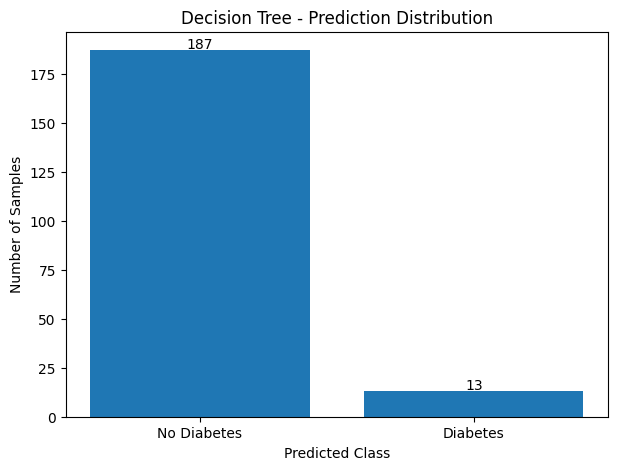

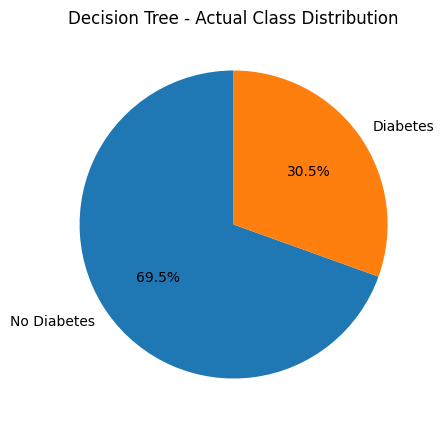

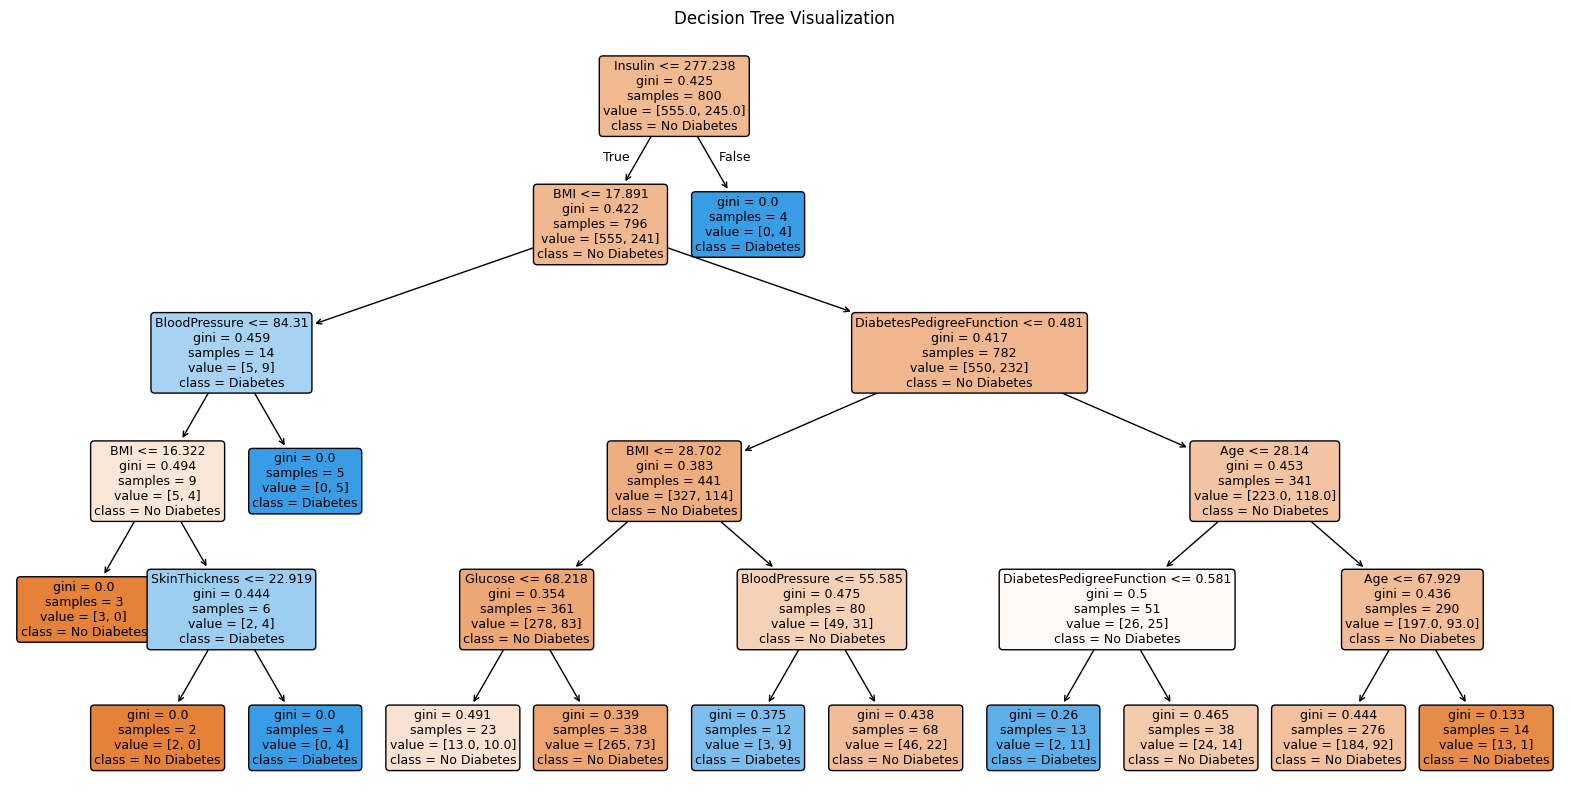


            FINAL RESULT
Decision Tree Accuracy = 67.00%

Graphs Generated:
1. Prediction Distribution
2. Actual Class Distribution
3. Decision Tree Visualization


In [3]:
# ============================================================
# DECISION TREE - DIABETES DATASET
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

# Upload diabetes.csv to Google Colab first

df = pd.read_csv("/content/Diabetes_prediction.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)


# ------------------------------------------------------------
# 3. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 4. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

# Outcome:
# 0 = No Diabetes
# 1 = Diabetes

X = df.drop("Diagnosis", axis=1)

y = df["Diagnosis"]


print("\nFeatures Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


# ------------------------------------------------------------
# 5. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ------------------------------------------------------------
# 6. CREATE DECISION TREE MODEL
# ------------------------------------------------------------

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)


# ------------------------------------------------------------
# 7. TRAIN MODEL
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 8. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------------------
# 9. CALCULATE ACCURACY
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n======================================")
print("       DECISION TREE RESULTS")
print("======================================")

print(
    "Accuracy:",
    accuracy
)

print(
    "Accuracy Percentage:",
    round(accuracy * 100, 2),
    "%"
)


# ------------------------------------------------------------
# 10. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ]
    )
)


# ============================================================
# GRAPH 1 - PREDICTION DISTRIBUTION
# ============================================================

prediction_counts = pd.Series(
    y_pred
).value_counts().sort_index()


plt.figure(figsize=(7, 5))

plt.bar(
    ["No Diabetes", "Diabetes"],
    prediction_counts.values
)

plt.xlabel("Predicted Class")

plt.ylabel("Number of Samples")

plt.title(
    "Decision Tree - Prediction Distribution"
)


# Display values
for i, value in enumerate(
    prediction_counts.values
):

    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )

plt.show()


# ============================================================
# GRAPH 2 - ACTUAL CLASS DISTRIBUTION
# ============================================================

actual_counts = pd.Series(
    y_test
).value_counts().sort_index()


plt.figure(figsize=(7, 5))

plt.pie(
    actual_counts.values,
    labels=[
        "No Diabetes",
        "Diabetes"
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Decision Tree - Actual Class Distribution"
)

plt.show()


# ============================================================
# GRAPH 3 - DECISION TREE VISUALIZATION
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[
        "No Diabetes",
        "Diabetes"
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Decision Tree Visualization"
)

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("            FINAL RESULT")
print("======================================")

print(
    f"Decision Tree Accuracy = {accuracy * 100:.2f}%"
)

print("\nGraphs Generated:")
print("1. Prediction Distribution")
print("2. Actual Class Distribution")
print("3. Decision Tree Visualization")